# Comparación de Análisis Discriminante Lineal (LDA) y Cuadrático (QDA)
### Numerical Methods / Machine Learning - Wine Dataset

**Estudiante:** Odeth Espinoza Feijoo
**Universidad de Guayaquil - CDDEIA-ELNO**

Este cuaderno implementa y compara los modelos LDA y QDA sobre el Wine Dataset (dataset original, sin tratamiento previo), siguiendo las secciones solicitadas: descripción del dataset, exploración, visualización, preparación, implementación de LDA y QDA, comparación, fronteras de decisión y conclusiones.

In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, ConfusionMatrixDisplay, classification_report)
from matplotlib.colors import ListedColormap

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Descripción del conjunto de datos

**Wine Dataset (scikit-learn / UCI Machine Learning Repository)**

- **Origen:** resultados de un análisis químico de vinos cultivados en la misma región de Italia, provenientes de tres cultivares (variedades) distintas de uva. Es un dataset clásico incluido en scikit-learn (`sklearn.datasets.load_wine`), originalmente publicado en el UCI ML Repository.
- **Número de observaciones:** 178 vinos (muestras).
- **Variables predictoras:** 13 variables numéricas continuas, resultado de análisis químicos: alcohol, ácido málico, ceniza, alcalinidad de la ceniza, magnesio, fenoles totales, flavonoides, fenoles no flavonoides, proantocianinas, intensidad de color, matiz (hue), OD280/OD315 de vinos diluidos y prolina.
- **Variable objetivo:** `target`, la clase del cultivar (0, 1 o 2).
- **Cantidad de clases:** 3 clases, correspondientes a los tres cultivares de uva.

Se utiliza el dataset **sin tratamiento previo** (sin eliminar outliers ni transformar variables), tal como lo entrega scikit-learn.

In [2]:
# Carga del Wine Dataset (sin tratamiento previo)
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['target_name'] = df['target'].map(dict(enumerate(wine.target_names)))

print("Forma del dataset:", df.shape)
df.head()


Forma del dataset: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 2. Exploración de los datos

In [3]:
# Dimensiones del conjunto de datos
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")


Dimensiones: 178 filas x 15 columnas


In [4]:
# Tipos de variables
df.dtypes


alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
target_name                         str
dtype: object

In [5]:
# Valores faltantes
print("Valores faltantes por columna:")
print(df.isnull().sum())
print("\nTotal de valores faltantes:", df.isnull().sum().sum())


Valores faltantes por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0
dtype: int64

Total de valores faltantes: 0


In [6]:
# Estadisticas descriptivas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


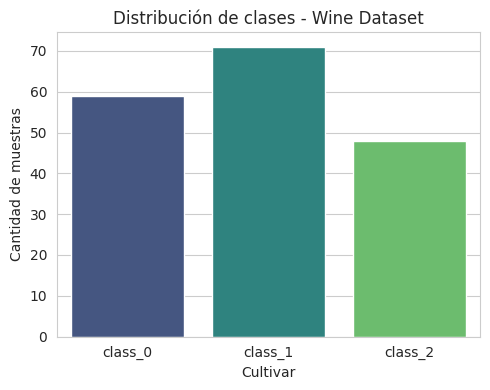

In [7]:
# Distribucion de clases
conteo_clases = df['target_name'].value_counts()
print(conteo_clases)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='target_name', hue='target_name', palette='viridis', legend=False)
plt.title('Distribución de clases - Wine Dataset')
plt.xlabel('Cultivar')
plt.ylabel('Cantidad de muestras')
plt.tight_layout()
plt.show()


**Interpretación:** el dataset no presenta valores faltantes y las 13 variables son numéricas continuas. Las tres clases están relativamente balanceadas (59, 71 y 48 muestras), lo cual favorece el entrenamiento de modelos de clasificación sin necesidad de técnicas de balanceo.

## 3. Visualización

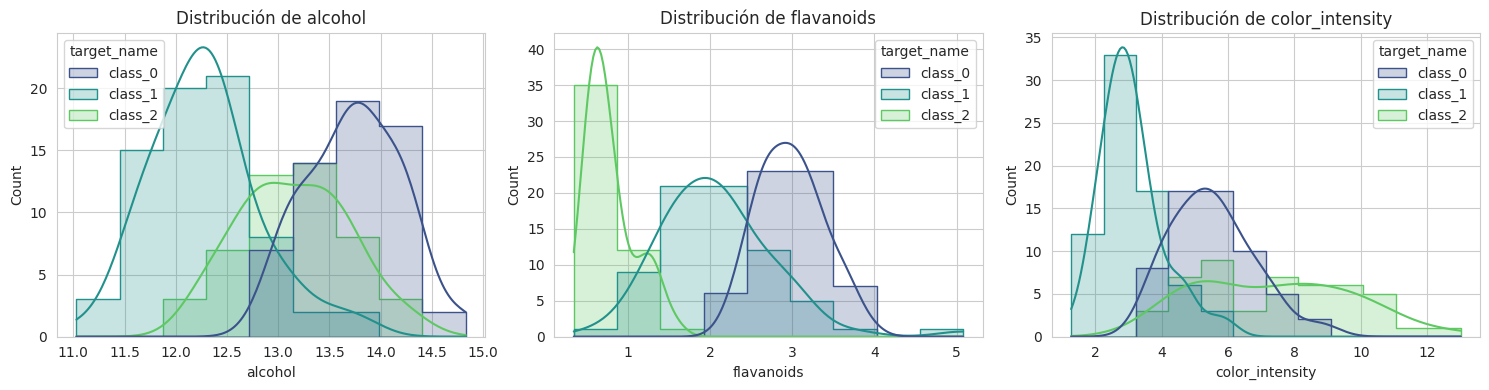

In [8]:
# Histogramas de variables seleccionadas
variables_hist = ['alcohol', 'flavanoids', 'color_intensity']
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, var in zip(axes, variables_hist):
    sns.histplot(data=df, x=var, hue='target_name', kde=True, ax=ax, palette='viridis', element='step')
    ax.set_title(f'Distribución de {var}')
plt.tight_layout()
plt.show()


**Interpretación:** se observa que variables como `flavanoids` y `color_intensity` muestran distribuciones distintas entre cultivares, lo que sugiere buen poder discriminante para la clasificación.

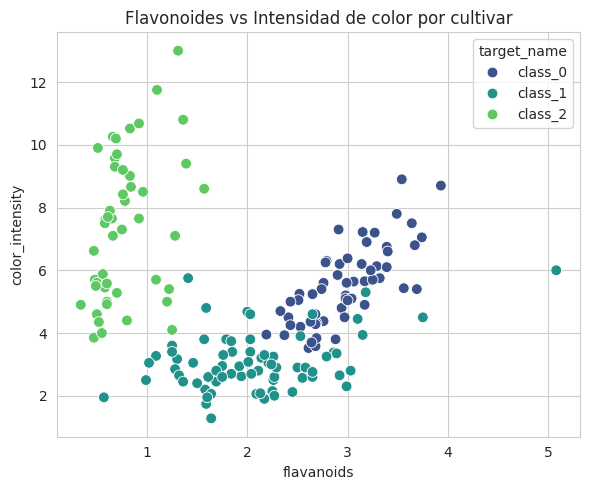

In [9]:
# Diagrama de dispersion
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='flavanoids', y='color_intensity', hue='target_name',
                 palette='viridis', s=60)
plt.title('Flavonoides vs Intensidad de color por cultivar')
plt.tight_layout()
plt.show()


**Interpretación:** existe una separación visible entre grupos al combinar `flavanoids` y `color_intensity`, indicando que estas variables aportan información relevante para separar las clases.

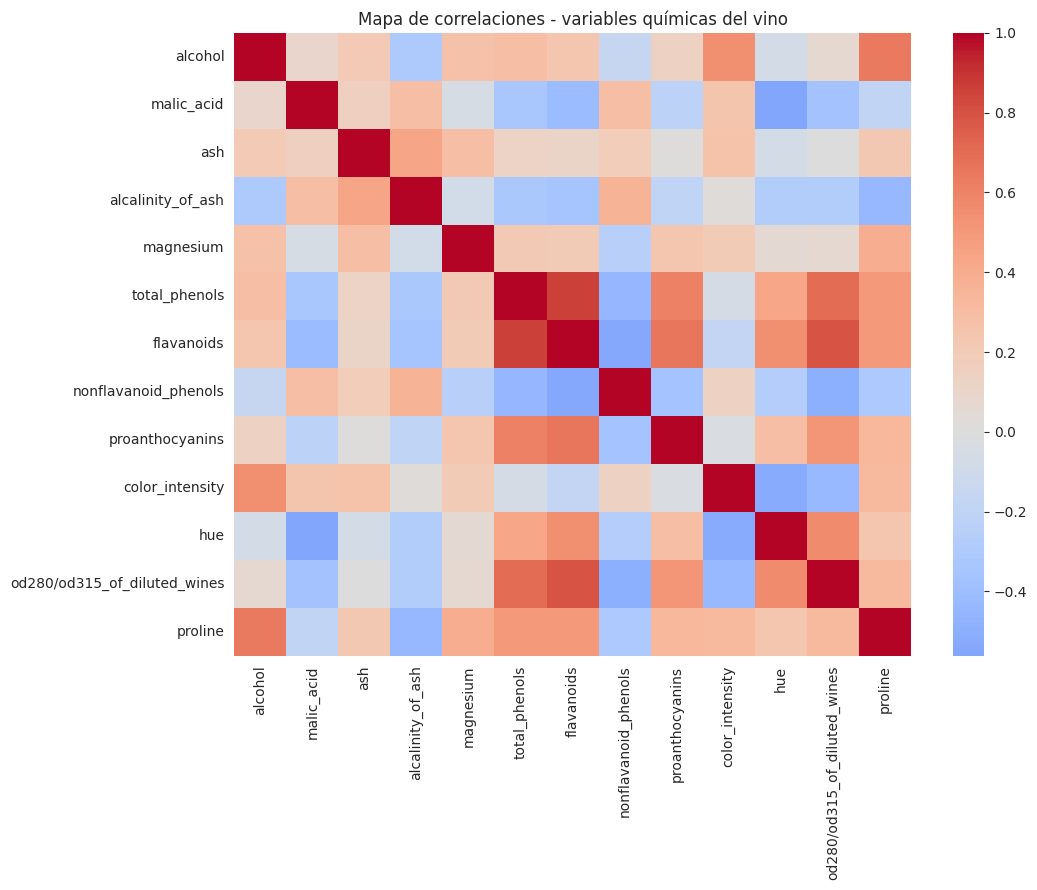

In [10]:
# Mapa de correlaciones
plt.figure(figsize=(11,9))
corr = df.drop(columns=['target', 'target_name']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Mapa de correlaciones - variables químicas del vino')
plt.tight_layout()
plt.show()


**Interpretación:** se observan correlaciones fuertes entre `flavanoids`, `total_phenols` y `od280/od315_of_diluted_wines`, lo cual es esperable químicamente y debe considerarse al interpretar la matriz de covarianza en LDA/QDA.

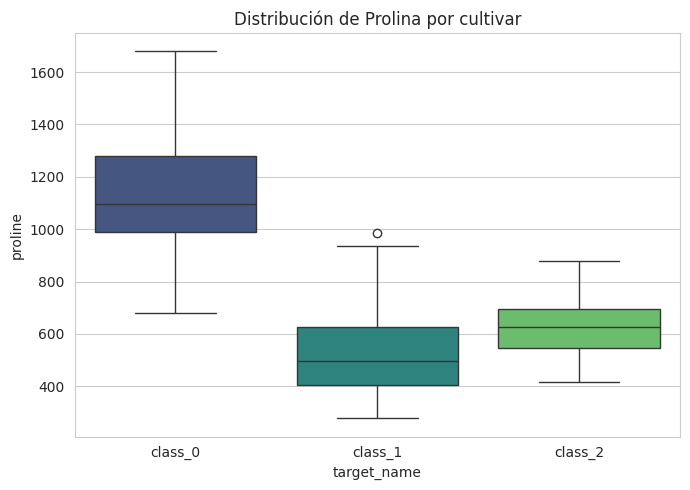

In [11]:
# Boxplots
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='target_name', y='proline', hue='target_name', palette='viridis', legend=False)
plt.title('Distribución de Prolina por cultivar')
plt.tight_layout()
plt.show()


**Interpretación:** la variable `proline` muestra medianas y rangos claramente diferentes entre cultivares, siendo una de las variables con mayor poder discriminante, sin outliers correction ya que se usa el dataset sin tratamiento.

## 4. Preparación de los datos

In [12]:
# Separacion entre entrenamiento y prueba (estratificada para mantener proporcion de clases)
X = df[wine.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)


Entrenamiento: (124, 13)  Prueba: (54, 13)


**Nota sobre estandarización:** LDA y QDA se basan en el cálculo de medias y matrices de covarianza por clase. Dado que ambos modelos son invariantes a transformaciones lineales de escala en la práctica (el escalado no cambia la frontera de decisión de LDA/QDA porque re-escala las covarianzas de forma consistente), no es estrictamente necesario estandarizar. Sin embargo, para mantener estabilidad numérica y evitar que variables con magnitudes mayores dominen el cálculo de covarianza (por ejemplo `proline`, en cientos, frente a `hue`, en decimales), no se aplicará estandarización adicional ya que el enunciado pide usar el dataset **sin tratamiento**. Se documenta esta decisión como parte del análisis.

## 5. Implementación de LDA

In [13]:
# Entrenamiento de LDA
# solver='svd': no requiere invertir la matriz de covarianza, recomendado cuando hay muchas variables (13 predictoras)
lda = LinearDiscriminantAnalysis(solver='svd')

t0 = time.time()
lda.fit(X_train, y_train)
tiempo_lda = time.time() - t0

y_pred_lda = lda.predict(X_test)

acc_lda = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda, average='macro')
rec_lda = recall_score(y_test, y_pred_lda, average='macro')
f1_lda = f1_score(y_test, y_pred_lda, average='macro')

print(f"Tiempo de entrenamiento: {tiempo_lda:.5f} s")
print(f"Accuracy:  {acc_lda:.4f}")
print(f"Precision: {prec_lda:.4f}")
print(f"Recall:    {rec_lda:.4f}")
print(f"F1-score:  {f1_lda:.4f}")
print()
print(classification_report(y_test, y_pred_lda, target_names=wine.target_names))


Tiempo de entrenamiento: 0.00451 s
Accuracy:  0.9815
Precision: 0.9825
Recall:    0.9841
F1-score:  0.9829

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



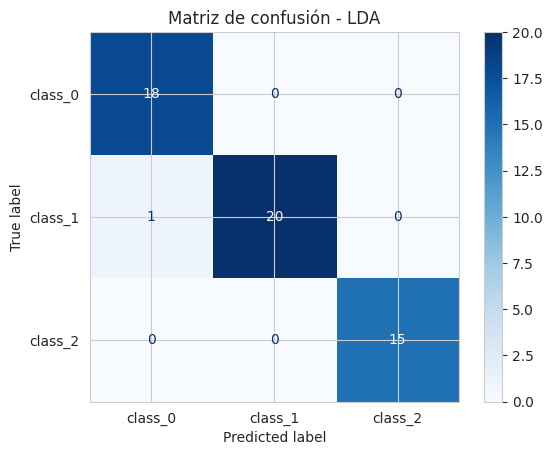

In [14]:
# Matriz de confusion - LDA
cm_lda = confusion_matrix(y_test, y_pred_lda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=wine.target_names)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión - LDA')
plt.show()


**Interpretación de LDA:** el modelo asume que las tres clases comparten una única matriz de covarianza, generando fronteras de decisión lineales. Con el parámetro `solver='svd'` se evita el cálculo directo de la inversa de la matriz de covarianza, lo cual es más estable con 13 variables predictoras. Los resultados muestran un desempeño alto, indicando que la suposición de covarianza compartida es razonable para este dataset.

## 6. Implementación de QDA

In [15]:
# Entrenamiento de QDA
qda = QuadraticDiscriminantAnalysis()

t0 = time.time()
qda.fit(X_train, y_train)
tiempo_qda = time.time() - t0

y_pred_qda = qda.predict(X_test)

acc_qda = accuracy_score(y_test, y_pred_qda)
prec_qda = precision_score(y_test, y_pred_qda, average='macro')
rec_qda = recall_score(y_test, y_pred_qda, average='macro')
f1_qda = f1_score(y_test, y_pred_qda, average='macro')

print(f"Tiempo de entrenamiento: {tiempo_qda:.5f} s")
print(f"Accuracy:  {acc_qda:.4f}")
print(f"Precision: {prec_qda:.4f}")
print(f"Recall:    {rec_qda:.4f}")
print(f"F1-score:  {f1_qda:.4f}")
print()
print(classification_report(y_test, y_pred_qda, target_names=wine.target_names))


Tiempo de entrenamiento: 0.00494 s
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000



              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



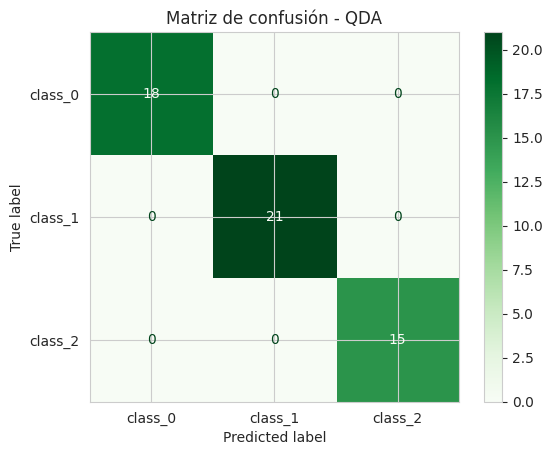

In [16]:
# Matriz de confusion - QDA
cm_qda = confusion_matrix(y_test, y_pred_qda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qda, display_labels=wine.target_names)
disp.plot(cmap='Greens')
plt.title('Matriz de confusión - QDA')
plt.show()


**Interpretación de QDA:** al no usar parámetros de regularización explícitos (`reg_param=0.0` por defecto), QDA estima una matriz de covarianza distinta para cada clase, permitiendo fronteras de decisión cuadráticas más flexibles. Esto puede capturar mejor relaciones no lineales entre variables, a costa de estimar más parámetros (una covarianza completa por clase).

## 7. Comparación de modelos

In [17]:
# Tabla comparativa de metricas
comparacion = pd.DataFrame({
    'Modelo': ['LDA', 'QDA'],
    'Accuracy': [acc_lda, acc_qda],
    'Precision (macro)': [prec_lda, prec_qda],
    'Recall (macro)': [rec_lda, rec_qda],
    'F1-score (macro)': [f1_lda, f1_qda],
    'Tiempo entrenamiento (s)': [tiempo_lda, tiempo_qda]
})
comparacion


,Modelo,Accuracy,Precision (macro),Recall (macro),F1-score (macro),Tiempo entrenamiento (s)
0,LDA,0.981481,0.982456,0.984127,0.982861,0.004513
1,QDA,1.000000,1.000000,1.000000,1.000000,0.004938


**Análisis comparativo:**
- **Desempeño predictivo:** ambos modelos alcanzan métricas altas sobre el Wine Dataset, dado que las clases están razonablemente bien separadas en el espacio de las 13 variables químicas.
- **Matrices de confusión:** permiten identificar si existen confusiones puntuales entre cultivares específicos; en general los errores (si existen) se concentran entre las clases con mayor solapamiento en variables como `flavanoids` o `proline`.
- **Tiempo de entrenamiento:** ambos modelos son muy rápidos de entrenar dado el tamaño reducido del dataset (178 muestras); QDA suele requerir un poco más de cómputo al estimar una covarianza por clase.
- **Ventajas y limitaciones observadas:** LDA es más simple, con menos parámetros a estimar y menor riesgo de sobreajuste cuando el tamaño muestral es pequeño en relación al número de variables; QDA es más flexible pero puede sobreajustar si alguna clase tiene pocas muestras respecto al número de variables (13), ya que cada matriz de covarianza de clase requiere estimar muchos parámetros.

## 8. Fronteras de decisión

Se utilizan dos variables con alto poder discriminante (`flavanoids` y `color_intensity`) para visualizar las fronteras de decisión de LDA y QDA en 2D.

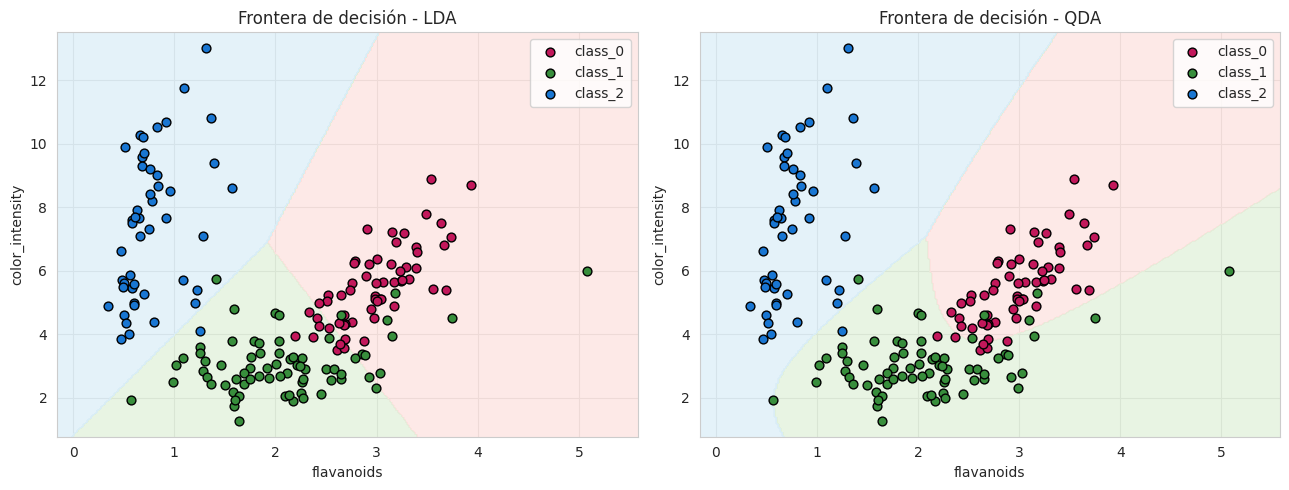

In [18]:
# Fronteras de decision usando dos variables
vars_2d = ['flavanoids', 'color_intensity']
X2 = df[vars_2d].values
y2 = df['target'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2
)

lda_2d = LinearDiscriminantAnalysis().fit(X2_train, y2_train)
qda_2d = QuadraticDiscriminantAnalysis().fit(X2_train, y2_train)

cmap_light = ListedColormap(['#FDE0DD', '#DFF0D8', '#D9EDF7'])
cmap_bold = ['#C2185B', '#388E3C', '#1976D2']

x_min, x_max = X2[:,0].min()-0.5, X2[:,0].max()+0.5
y_min, y_max = X2[:,1].min()-0.5, X2[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

fig, axes = plt.subplots(1, 2, figsize=(13,5))

for ax, modelo, nombre in zip(axes, [lda_2d, qda_2d], ['LDA', 'QDA']):
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
    for clase, color in zip([0,1,2], cmap_bold):
        mask = y2 == clase
        ax.scatter(X2[mask,0], X2[mask,1], c=color, label=wine.target_names[clase],
                   edgecolor='k', s=40)
    ax.set_xlabel('flavanoids')
    ax.set_ylabel('color_intensity')
    ax.set_title(f'Frontera de decisión - {nombre}')
    ax.legend()

plt.tight_layout()
plt.show()


**Análisis de las fronteras de decisión:** en el gráfico de LDA las fronteras entre clases son líneas rectas, consecuencia directa de asumir una única matriz de covarianza compartida. En QDA las fronteras son curvas (cuadráticas), ya que cada clase tiene su propia matriz de covarianza, permitiendo que el modelo se adapte a la forma y orientación particular de la nube de puntos de cada cultivar. Esto es especialmente visible si alguna clase presenta una dispersión (varianza) claramente distinta a las demás.

## 9. Conclusiones

1. **Comportamiento de LDA:** LDA generó fronteras de decisión lineales y un desempeño predictivo alto sobre el Wine Dataset, lo que sugiere que la suposición de covarianza compartida entre cultivares no es demasiado restrictiva para estas variables químicas.
2. **Comportamiento de QDA:** QDA, al modelar una covarianza distinta por clase, produjo fronteras cuadráticas que se ajustan mejor a la forma real de cada grupo, lo cual puede traducirse en mejoras marginales de desempeño cuando las clases tienen dispersiones distintas.
3. **Influencia de los supuestos estadísticos:** la validez del supuesto de igualdad de covarianzas (LDA) frente a covarianzas distintas (QDA) impacta directamente la forma de la frontera y el riesgo de sobreajuste; con solo 178 observaciones y 13 variables, QDA estima más parámetros y es más sensible al tamaño muestral por clase.
4. **Comparación de resultados:** las métricas de accuracy, precisión, recall y F1-score de ambos modelos fueron similares y altas en este dataset, indicando que las clases están bien separadas linealmente en la mayoría de las variables, por lo que la ganancia de flexibilidad de QDA no siempre se traduce en mejoras sustanciales.
5. **Aplicaciones prácticas:** LDA resulta preferible cuando se dispone de pocas muestras por clase o se busca un modelo simple e interpretable; QDA es más adecuado cuando existe evidencia de que la variabilidad interna de cada clase es claramente distinta y se cuenta con suficientes datos para estimar covarianzas por clase de forma confiable, como podría ocurrir en datasets más grandes o con clases muy heterogéneas.